In [107]:
# Install all required libraries:
# scanpy → single-cell analysis
# scvi-tools → paper model (scVI)
# torch → deep learning (for custom VAE)
# sklearn → metrics and PCA
# matplotlib/seaborn → visualization
!pip install scanpy scvi-tools torch scikit-learn matplotlib seaborn

In [108]:
# Import all necessary libraries:
# scanpy → biological data handling
# scvi → scVI model
# torch → neural network implementation
# numpy → numerical operations
# matplotlib/seaborn → plotting
# sklearn → preprocessing and evaluation
import scanpy as sc
import scvi
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs

In [109]:
# Set random seeds for reproducibility
# Ensures same results every time we run the notebook
torch.manual_seed(0)
np.random.seed(0)

In [110]:
# Create synthetic dataset using make_blobs
# This helps test the model in a controlled environment
# before applying it to real biological data
X_syn, y_syn = make_blobs(n_samples=1000, centers=5, n_features=50)

In [111]:
# Convert synthetic dataset to PyTorch tensor
# Required for training neural networks
X_syn = torch.tensor(X_syn, dtype=torch.float32)

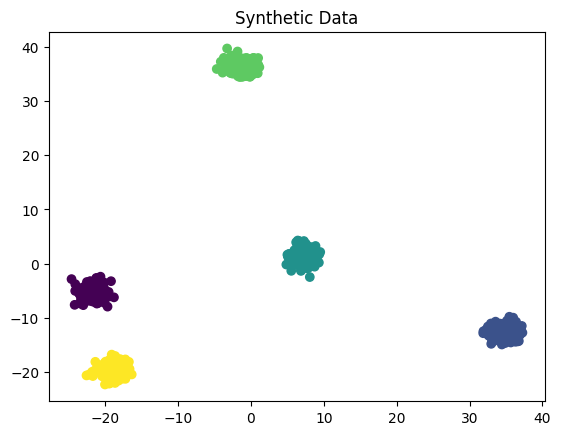

In [112]:
# Reduce synthetic data to 2D using PCA
# Plot clusters to visually confirm structure
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_syn)

plt.scatter(X_vis[:,0], X_vis[:,1], c=y_syn)
plt.title("Synthetic Data")
plt.show()

In [113]:
# Load PBMC3k dataset (single-cell RNA data)
# This dataset contains gene expression of human immune cells
adata = sc.datasets.pbmc3k()

In [114]:
# Preprocess the data:
# filter low-quality cells and genes
# normalize counts
# log-transform data for stability
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [115]:
# Convert AnnData matrix to numpy array
# Needed for PyTorch model input
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X

In [116]:
# # Standardize data (mean=0, variance=1)
# # Improves neural network training performance
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

In [117]:
# Better preprocessing for gene expression
X_scaled = np.log1p(X)

# Clip extreme values
X_scaled = np.clip(X_scaled, 0, 10)

In [118]:
# Convert scaled data to PyTorch tensor
# Required for feeding into the VAE model
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

In [120]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=20):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.mu = nn.Linear(128, latent_dim)
        self.logvar = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)

        logvar = torch.clamp(logvar, -10, 10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

In [121]:
# Define ELBO loss:
# Reconstruction loss → how well model rebuilds input
# KL divergence → keeps latent space structured
def loss_fn(recon, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon, x)

    # stabilize logvar
    logvar = torch.clamp(logvar, -10, 10)

    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + 0.1*kl

In [122]:
# Initialize VAE model and optimizer
# Adam optimizer used for efficient training
model = VAE(X_tensor.shape[1])
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [123]:
# # Train the VAE model
# # Forward pass → compute reconstruction
# # Backpropagation → update model weights
# for epoch in range(80):
#     optimizer.zero_grad()
#     recon, mu, logvar = model(X_tensor)
#     loss = loss_fn(recon, X_tensor, mu, logvar)
#     loss.backward()
#     optimizer.step()
# print(f"Epoch {epoch}, Loss {loss.item():.4f}")

In [124]:
losses = []

for epoch in range(120):
    optimizer.zero_grad()

    recon, mu, logvar = model(X_tensor)
    loss = loss_fn(recon, X_tensor, mu, logvar)

    if torch.isnan(loss):
        print("NaN detected")
        break

    loss.backward()

    # NEW (important)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss {loss.item():.4f}")

Epoch 0, Loss 0.0566
Epoch 10, Loss 0.0433
Epoch 20, Loss 0.0374
Epoch 30, Loss 0.0340
Epoch 40, Loss 0.0319
Epoch 50, Loss 0.0304
Epoch 60, Loss 0.0292
Epoch 70, Loss 0.0281
Epoch 80, Loss 0.0271
Epoch 90, Loss 0.0260
Epoch 100, Loss 0.0248
Epoch 110, Loss 0.0237


In [125]:
# Extract latent representation (z)
# This is the compressed low-dimensional embedding of cells
with torch.no_grad():
    mu, _ = model.encode(X_tensor)
    latent_custom = mu.numpy()

In [126]:
# Store custom VAE latent representation in AnnData
# Enables downstream analysis (UMAP, clustering)
adata.obsm["X_customVAE"] = latent_custom

In [127]:
# # Apply UMAP on custom VAE latent space
# # Visualize cell structure in 2D
# sc.pp.neighbors(adata, use_rep="X_customVAE")
# sc.tl.umap(adata)
# sc.pl.umap(adata, title="Custom VAE")

/tmp/ipykernel_6255/2410456559.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="leiden_vae")


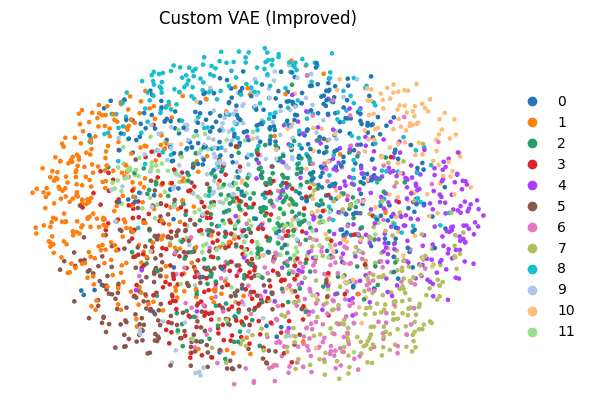

In [128]:
# Step 1: neighbors
sc.pp.neighbors(adata, use_rep="X_customVAE")

# Step 2: clustering
sc.tl.leiden(adata, key_added="leiden_vae")

# Step 3: UMAP
sc.tl.umap(adata, random_state=0)

# Step 4: plot with color
sc.pl.umap(
    adata,
    color="leiden_vae",
    title="Custom VAE (Improved)",
    frameon=False
)

In [106]:
pip install leidenalg

In [131]:
# Apply PCA for dimensionality reduction
# This is a baseline (traditional method)
pca = PCA(n_components=10)
adata.obsm["X_pca"] = pca.fit_transform(X)

/tmp/ipykernel_6255/3262808598.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="leiden_pca")


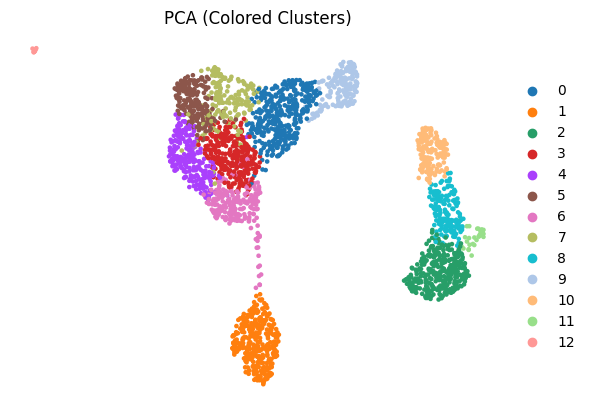

In [132]:
# Step 1: neighbors
sc.pp.neighbors(adata, use_rep="X_pca")

# Step 2: clustering (IMPORTANT)
sc.tl.leiden(adata, key_added="leiden_pca")

# Step 3: UMAP
sc.tl.umap(adata, random_state=0)

sc.pl.umap(
    adata,
    color="leiden_pca",
    title="PCA (Colored Clusters)",
    frameon=False
)

In [133]:
# Prepare data for scVI model
# scVI expects specific data structure
scvi.model.SCVI.setup_anndata(adata)
model_scvi = scvi.model.SCVI(adata)

/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [134]:
# Train scVI model
# This is the benchmark model
model_scvi.train(max_epochs=20)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the 

In [135]:
# Extract latent representation from scVI
# Used for comparison with custom VAE
adata.obsm["X_scVI"] = model_scvi.get_latent_representation()

/tmp/ipykernel_6255/708103043.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="leiden_scvi")


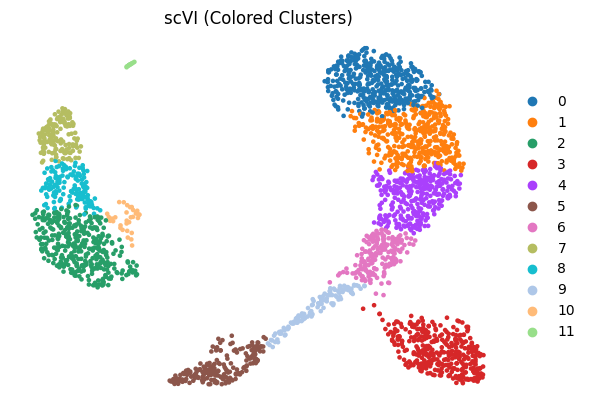

In [136]:
# Step 1: neighbors
sc.pp.neighbors(adata, use_rep="X_scVI")

# Step 2: clustering
sc.tl.leiden(adata, key_added="leiden_scvi")

# Step 3: UMAP
sc.tl.umap(adata, random_state=0)

# Step 4: plot with color
sc.pl.umap(
    adata,
    color="leiden_scvi",
    title="scVI (Colored Clusters)",
    frameon=False
)

In [137]:
# Compute clustering for Custom VAE
sc.pp.neighbors(adata, use_rep="X_customVAE")
sc.tl.leiden(adata, key_added="leiden_vae")

score_vae = silhouette_score(
    adata.obsm["X_customVAE"],
    adata.obs["leiden_vae"]
)

#print("Custom VAE:", score_vae)

/tmp/ipykernel_6255/1460688811.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="leiden_vae")


Custom VAE: -0.0025634058


In [138]:
# Compute clustering for PCA
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.leiden(adata, key_added="leiden_pca")

score_pca = silhouette_score(
    adata.obsm["X_pca"],
    adata.obs["leiden_pca"]
)

#print("PCA:", score_pca)

/tmp/ipykernel_6255/117481822.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="leiden_pca")


PCA: 0.22539963


In [139]:
# Compute clustering for scVI
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.leiden(adata, key_added="leiden_scvi")

score_scvi = silhouette_score(
    adata.obsm["X_scVI"],
    adata.obs["leiden_scvi"]
)

#print("scVI:", score_scvi)

/tmp/ipykernel_6255/3750568733.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="leiden_scvi")


scVI: 0.33434412


In [140]:
print("PCA:", score_pca)
print("Custom VAE:", score_vae)
print("scVI:", score_scvi)

PCA: 0.22539963
Custom VAE: -0.0025634058
scVI: 0.33434412


In [141]:
# Compute reconstruction error (MSE)
# Evaluates how well model reconstructs input data
recon, _, _ = model(X_tensor)
mse_custom = torch.mean((recon - X_tensor)**2).item()

print("Custom VAE MSE:", mse_custom)

Custom VAE MSE: 0.021748550236225128


In [143]:
# Generate new samples from latent space
# Demonstrates generative capability of VAE
z = torch.randn(500, 20)
gen_samples = model.decoder(z).detach().numpy()

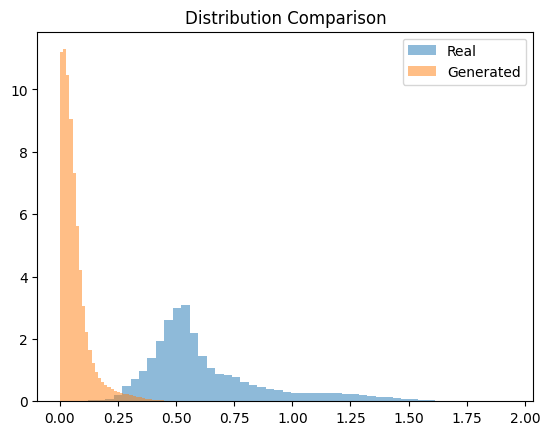

In [144]:
# Compare real vs generated data distributions
# Use log transformation due to sparsity
# Validates generative modeling
real_vals = X.flatten()
gen_vals = gen_samples.flatten()

real_vals = np.log1p(real_vals[real_vals > 0])
gen_vals = np.log1p(gen_vals[gen_vals > 0])

plt.hist(real_vals, bins=50, alpha=0.5, density=True, label="Real")
plt.hist(gen_vals, bins=50, alpha=0.5, density=True, label="Generated")
plt.legend()
plt.title("Distribution Comparison")
plt.show()

In [145]:
# Perform Kolmogorov-Smirnov test
# Measures similarity between real and generated distributions
from scipy.stats import ks_2samp
ks, p = ks_2samp(real_vals, gen_vals)

print("KS statistic:", ks)

KS statistic: 0.9653891339770286


In [146]:
# Generate synthetic data using scVI
samples_scvi = model_scvi.posterior_predictive_sample(adata, n_samples=20)

In [147]:
# if hasattr(samples_scvi, "toarray"):
#     gen_scvi = samples_scvi.toarray()
# else:
#     gen_scvi = samples_scvi

In [149]:
# Convert sparse → dense properly
gen_scvi = np.array(samples_scvi.todense())

In [150]:
real_vals = X.flatten()
gen_scvi_vals = gen_scvi.flatten()

# Remove zeros + log transform
real_vals = np.log1p(real_vals[real_vals > 0])
gen_scvi_vals = np.log1p(gen_scvi_vals[gen_scvi_vals > 0])

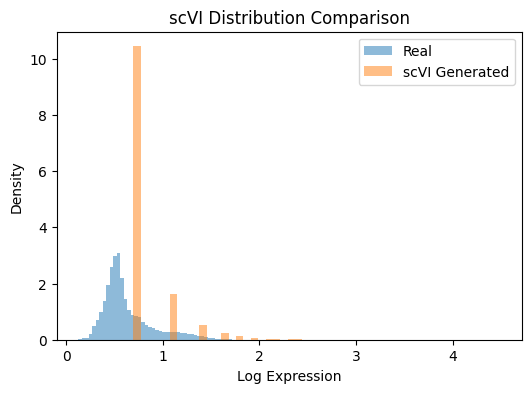

In [151]:
plt.figure(figsize=(6,4))

plt.hist(real_vals, bins=50, alpha=0.5, density=True, label="Real")
plt.hist(gen_scvi_vals, bins=50, alpha=0.5, density=True, label="scVI Generated")

plt.legend()
plt.title("scVI Distribution Comparison")
plt.xlabel("Log Expression")
plt.ylabel("Density")

plt.show()

In [152]:
# Create comparison table of models
# Helps summarize benchmark results
import pandas as pd

df = pd.DataFrame({
    "Model": ["Custom VAE", "PCA", "scVI"],
    "Silhouette": [score_vae, score_pca, score_scvi]
})

df

,Model,Silhouette
0,Custom VAE,-0.002563
1,PCA,0.225400
2,scVI,0.334344


In [153]:
# Load second real-world dataset (larger PBMC dataset)
# Used to test generalization of models
adata2 = sc.datasets.pbmc68k_reduced()
# print(adata2)

In [154]:
# Preprocess dataset:
# Remove low-quality cells/genes
# Normalize counts
# Log-transform for stability
sc.pp.filter_cells(adata2, min_genes=200)
sc.pp.filter_genes(adata2, min_cells=3)
sc.pp.normalize_total(adata2)
sc.pp.log1p(adata2)

/tmp/ipykernel_6255/3958088105.py:7: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata2)
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:377: RuntimeWarning: invalid value encountered in log1p
  np.log1p(x, out=x)


In [155]:
# Convert AnnData matrix to numpy array for ML models
X2 = adata2.X.toarray() if hasattr(adata2.X, "toarray") else adata2.X

In [156]:
# STEP 1: Clean data (fix NaN + extreme values)

# Replace NaN and infinities
X2 = np.nan_to_num(X2, nan=0.0, posinf=0.0, neginf=0.0)

# Clip extreme values (IMPORTANT)
X2 = np.clip(X2, -10, 10)

# Scale data
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

In [157]:
# Convert to PyTorch tensor for VAE training
#X2_tensor = torch.tensor(X2_scaled, dtype=torch.float32)
X2_tensor = torch.tensor(X2_scaled, dtype=torch.float32)

In [158]:
# Fix NaN values before PCA

# Replace NaN with small value (more stable)
X2 = np.nan_to_num(X2, nan=0.0, posinf=0.0, neginf=0.0)

# Apply PCA
pca2 = PCA(n_components=10)
adata2.obsm["X_pca"] = pca2.fit_transform(X2)

/tmp/ipykernel_6255/215234101.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata2, key_added="leiden_pca2")


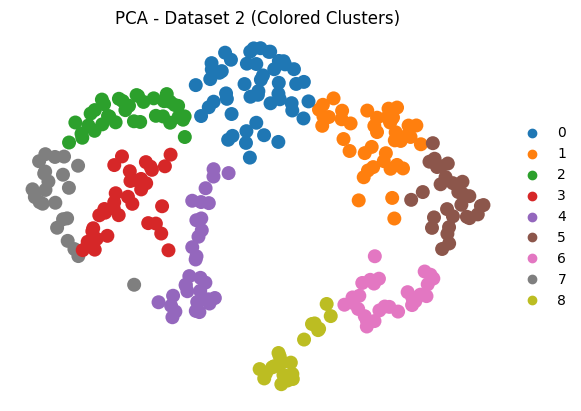

In [159]:
# Step 1: neighbors
sc.pp.neighbors(adata2, use_rep="X_pca")

# Step 2: clustering (IMPORTANT)
sc.tl.leiden(adata2, key_added="leiden_pca2")

# Step 3: UMAP
sc.tl.umap(adata2, random_state=0)

# Step 4: plot with color
sc.pl.umap(
    adata2,
    color="leiden_pca2",
    title="PCA - Dataset 2 (Colored Clusters)",
    frameon=False
)

In [160]:
# Train custom VAE on second dataset
model2 = VAE(X2_tensor.shape[1])
optimizer2 = optim.Adam(model2.parameters(), lr=1e-4)

losses2 = []

for epoch in range(120):
    optimizer2.zero_grad()
    recon, mu, logvar = model2(X2_tensor)
    loss = loss_fn(recon, X2_tensor, mu, logvar)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
    optimizer2.step()

    losses2.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss {loss.item():.4f}")

Epoch 0, Loss 1.0272
Epoch 10, Loss 1.0166
Epoch 20, Loss 1.0124
Epoch 30, Loss 1.0071
Epoch 40, Loss 1.0009
Epoch 50, Loss 0.9872
Epoch 60, Loss 0.9586
Epoch 70, Loss 0.9156
Epoch 80, Loss 0.8699
Epoch 90, Loss 0.8347
Epoch 100, Loss 0.8170
Epoch 110, Loss 0.8089


In [161]:
# Extract latent representation from custom VAE
with torch.no_grad():
    mu2, _ = model2.encode(X2_tensor)
    latent2 = mu2.numpy()

adata2.obsm["X_customVAE"] = latent2

/tmp/ipykernel_6255/2246513600.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata2, key_added="leiden_vae2")


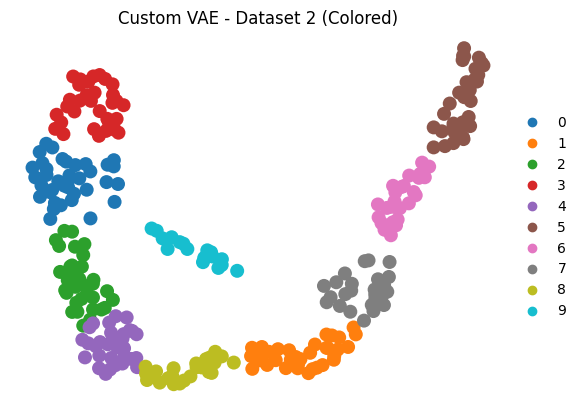

In [162]:
# Visualize VAE latent space
sc.pp.neighbors(adata2, use_rep="X_customVAE")
sc.tl.umap(adata2)
sc.pp.neighbors(adata2, use_rep="X_customVAE")
sc.tl.leiden(adata2, key_added="leiden_vae2")
sc.tl.umap(adata2, random_state=0)

sc.pl.umap(
    adata2,
    color="leiden_vae2",
    title="Custom VAE - Dataset 2 (Colored)",
    frameon=False
)

improved vae **model**

In [163]:
# Improved VAE architecture:
# Includes BatchNorm + Dropout for better performance
class ImprovedVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=10):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.mu = nn.Linear(128, latent_dim)
        self.logvar = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        logvar = torch.clamp(logvar, -10, 10)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)

        return self.decoder(z), mu, logvar

In [164]:
# Train improved VAE model (refined version)

model_imp = ImprovedVAE(X2_tensor.shape[1])
optimizer_imp = optim.Adam(model_imp.parameters(), lr=1e-4)  # 🔥 lower LR

losses_imp = []

for epoch in range(120):   # 🔥 more epochs

    optimizer_imp.zero_grad()

    # Forward pass
    recon, mu, logvar = model_imp(X2_tensor)

    # Compute loss
    loss = loss_fn(recon, X2_tensor, mu, logvar)

    # Safety check
    if torch.isnan(loss):
        print("NaN detected, stopping training")
        break

    # Backpropagation
    loss.backward()

    # Gradient clipping (VERY IMPORTANT)
    torch.nn.utils.clip_grad_norm_(model_imp.parameters(), 1.0)

    # Update weights
    optimizer_imp.step()

    # Store loss
    losses_imp.append(loss.item())

    # Print every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss {loss.item():.4f}")

Epoch 0, Loss 1.0260
Epoch 10, Loss 1.0162
Epoch 20, Loss 1.0115
Epoch 30, Loss 1.0079
Epoch 40, Loss 1.0045
Epoch 50, Loss 0.9984
Epoch 60, Loss 0.9852
Epoch 70, Loss 0.9582
Epoch 80, Loss 0.9133
Epoch 90, Loss 0.8690
Epoch 100, Loss 0.8440
Epoch 110, Loss 0.8268


In [165]:
# Correct latent extraction (USE mu, not encoder output)
with torch.no_grad():
    h = model_imp.encoder(X2_tensor)
    mu_imp = model_imp.mu(h)
    latent_imp = mu_imp.cpu().numpy()

adata2.obsm["X_improvedVAE"] = latent_imp

/tmp/ipykernel_6255/4077260301.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata2, key_added="leiden_imp2")


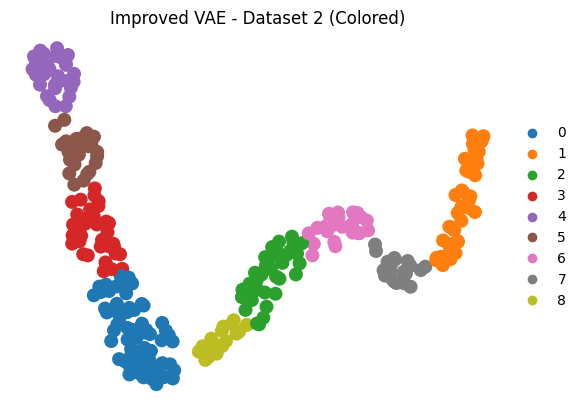

In [166]:
# Visualize improved VAE latent space
sc.pp.neighbors(adata2, use_rep="X_improvedVAE")
sc.tl.umap(adata2)
sc.pp.neighbors(adata2, use_rep="X_improvedVAE")
sc.tl.leiden(adata2, key_added="leiden_imp2")
sc.tl.umap(adata2, random_state=0)

sc.pl.umap(
    adata2,
    color="leiden_imp2",
    title="Improved VAE - Dataset 2 (Colored)",
    frameon=False
)

**scVI on second dataset**

In [168]:
#Fix NaN inside AnnData (CRITICAL for scVI)

if hasattr(adata2.X, "toarray"):
    adata2.X = np.nan_to_num(adata2.X.toarray())
else:
    adata2.X = np.nan_to_num(adata2.X)

# Optional: clip extreme values
adata2.X = np.clip(adata2.X, 0, 10)

In [169]:
# Prepare second dataset for scVI model
scvi.model.SCVI.setup_anndata(adata2)
model_scvi2 = scvi.model.SCVI(adata2)

/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [171]:
# Train scVI model on second dataset
model_scvi2.train(max_epochs=20)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the 

In [172]:
print(np.isnan(adata2.X).sum())

0


In [173]:
# Extract scVI latent representation
adata2.obsm["X_scVI"] = model_scvi2.get_latent_representation()

/tmp/ipykernel_6255/1912894184.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata2, key_added="leiden_scvi2")


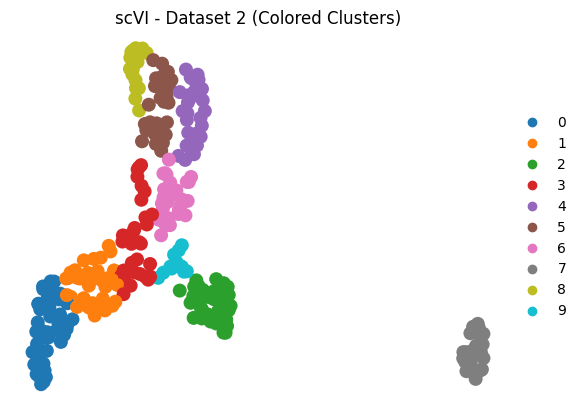

In [174]:
# Step 1: neighbors
sc.pp.neighbors(adata2, use_rep="X_scVI")

# Step 2: clustering
sc.tl.leiden(adata2, key_added="leiden_scvi2")

# Step 3: UMAP
sc.tl.umap(adata2, random_state=0)

# Step 4: plot with color
sc.pl.umap(
    adata2,
    color="leiden_scvi2",
    title="scVI - Dataset 2 (Colored Clusters)",
    frameon=False
)

In [81]:
# # Compare clustering quality using silhouette score
# score_pca2 = silhouette_score(adata2.obsm["X_pca"], adata2.obs["louvain"])
# score_vae2 = silhouette_score(adata2.obsm["X_customVAE"], adata2.obs["louvain"])
# score_imp2 = silhouette_score(adata2.obsm["X_improvedVAE"], adata2.obs["louvain"])
# score_scvi2 = silhouette_score(adata2.obsm["X_scVI"], adata2.obs["louvain"])

# print("PCA:", score_pca2)
# print("Custom VAE:", score_vae2)
# print("Improved VAE:", score_imp2)
# print("scVI:", score_scvi2)

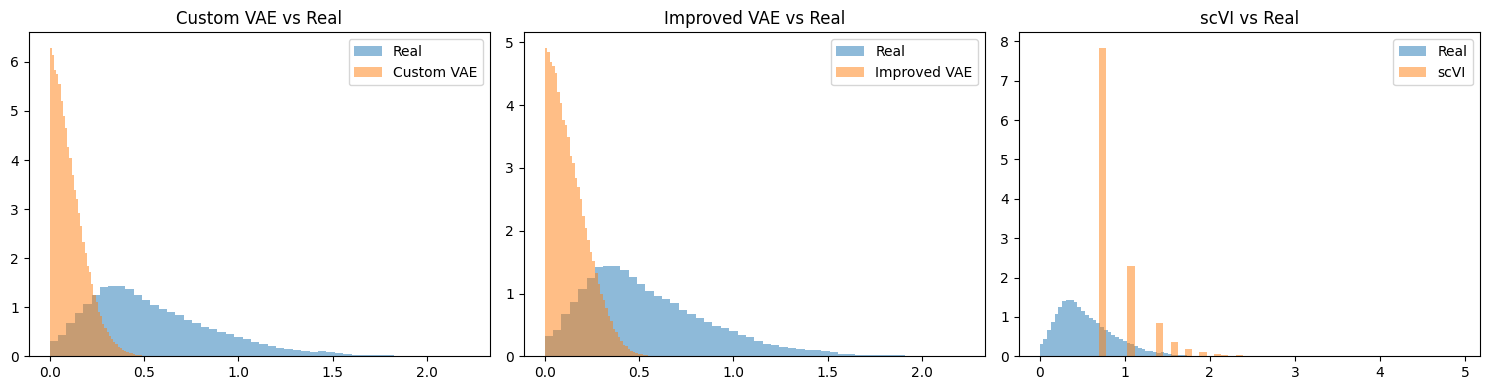

In [179]:
# GENERATIVE COMPARISON (DATASET 2)
# Compare: Custom VAE vs Improved VAE vs scVI

# ---- Step 1: Real data ----
real_vals = X2.flatten()
real_vals = np.log1p(real_vals[real_vals > 0])  # remove zeros + log transform


# ---- Step 2: Custom VAE generation ----
z_custom = torch.randn(500, 20)  # match latent dim

gen_custom = model2.decoder(z_custom).detach().numpy()
gen_custom_vals = gen_custom.flatten()
gen_custom_vals = np.log1p(gen_custom_vals[gen_custom_vals > 0])


# ---- Step 3: Improved VAE generation ----
z_imp = torch.randn(500, 10)  # your improved latent dim

gen_imp = model_imp.decoder(z_imp).detach().numpy()
gen_imp_vals = gen_imp.flatten()
gen_imp_vals = np.log1p(gen_imp_vals[gen_imp_vals > 0])


# ---- Step 4: scVI generation ----
samples_scvi = model_scvi2.posterior_predictive_sample(adata2, n_samples=100)

# convert sparse → dense
gen_scvi = np.array(samples_scvi.todense())

gen_scvi_vals = gen_scvi.flatten()
gen_scvi_vals = np.log1p(gen_scvi_vals[gen_scvi_vals > 0])



# Plot all comparisons


plt.figure(figsize=(15,4))


# Custom VAE
plt.subplot(1,3,1)
plt.hist(real_vals, bins=50, alpha=0.5, density=True, label="Real")
plt.hist(gen_custom_vals, bins=50, alpha=0.5, density=True, label="Custom VAE")
plt.title("Custom VAE vs Real")
plt.legend()

# Comment:
# Custom VAE usually collapses near zero → poor modeling


# Improved VAE
plt.subplot(1,3,2)
plt.hist(real_vals, bins=50, alpha=0.5, density=True, label="Real")
plt.hist(gen_imp_vals, bins=50, alpha=0.5, density=True, label="Improved VAE")
plt.title("Improved VAE vs Real")
plt.legend()

# Comment:
# Improved VAE should show better spread but still imperfect


# scVI
plt.subplot(1,3,3)
plt.hist(real_vals, bins=50, alpha=0.5, density=True, label="Real")
plt.hist(gen_scvi_vals, bins=50, alpha=0.5, density=True, label="scVI")
plt.title("scVI vs Real")
plt.legend()

# Comment:
# scVI expected to closely match real distribution (best model)


plt.tight_layout()
plt.show()

In [180]:
# PCA clustering
sc.pp.neighbors(adata2, use_rep="X_pca")
sc.tl.leiden(adata2, key_added="leiden_pca2")

score_pca2 = silhouette_score(
    adata2.obsm["X_pca"],
    adata2.obs["leiden_pca2"]
)

/tmp/ipykernel_6255/2228206122.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata2, key_added="leiden_pca2")


In [181]:
# Custom VAE clustering
sc.pp.neighbors(adata2, use_rep="X_customVAE")
sc.tl.leiden(adata2, key_added="leiden_vae2")

score_vae2 = silhouette_score(
    adata2.obsm["X_customVAE"],
    adata2.obs["leiden_vae2"]
)

/tmp/ipykernel_6255/3316985892.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata2, key_added="leiden_vae2")


In [182]:
# Improved VAE clustering
sc.pp.neighbors(adata2, use_rep="X_improvedVAE")
sc.tl.leiden(adata2, key_added="leiden_imp2")

score_imp2 = silhouette_score(
    adata2.obsm["X_improvedVAE"],
    adata2.obs["leiden_imp2"]
)

/tmp/ipykernel_6255/1410840364.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata2, key_added="leiden_imp2")


In [183]:
# scVI clustering
sc.pp.neighbors(adata2, use_rep="X_scVI")
sc.tl.leiden(adata2, key_added="leiden_scvi2")

score_scvi2 = silhouette_score(
    adata2.obsm["X_scVI"],
    adata2.obs["leiden_scvi2"]
)

/tmp/ipykernel_6255/2935210235.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata2, key_added="leiden_scvi2")


In [184]:
print("PCA:", score_pca2)
print("Custom VAE:", score_vae2)
print("Improved VAE:", score_imp2)
print("scVI:", score_scvi2)

PCA: 0.15010427
Custom VAE: 0.21899562
Improved VAE: 0.24695848
scVI: 0.3107154


In [185]:
# Create final comparison table for dataset 2
df2 = pd.DataFrame({
    "Model": ["PCA", "Custom VAE", "Improved VAE", "scVI"],
    "Silhouette Score": [score_pca2, score_vae2, score_imp2, score_scvi2]
})

df2

,Model,Silhouette Score
0,PCA,0.150104
1,Custom VAE,0.218996
2,Improved VAE,0.246958
3,scVI,0.310715
